# 🕸️ Network Logic Engine: Centrality & Influence Analysis

**Objective:** To identify the most influential nodes within an unweighted, undirected graph using advanced network logic algorithms.

**Academic Context:** This project digitally implements the abstract concepts from my **300 ECTS Mathematics coursework** at DCRUST, specifically bridging:
* **Matrix Algebra:** Utilizing Eigenvector Centrality to calculate influence based on the spectral radius of the adjacency matrix.
* **Theory of Automata & Algorithms:** Simulating deterministic state paths and graph traversal.
* **Application:** This is the foundational mathematics behind modern Search Engine Optimization (PageRank) and Social Network Architecture.

In [1]:
# Import the standard Python Scientific and Network Analysis stack
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

print("Libraries successfully imported! Network Engine ready.")

Libraries successfully imported! Network Engine ready.


### 1. Generating the Network Topology
We simulate a complex network (like a server cluster, social network, or citation graph) with 15 interconnected nodes. The connections represent data flow or relationships.


In [3]:
# Initialize an undirected graph
G = nx.Graph()

# Define the network connections (Edges)
edges = [
    (1,2), (1,3), (1,4), (2,4), (3,4), (4,5), 
    (5,6), (5,7), (6,8), (7,8), (8,9), (8,10),
    (9,11), (10,11), (11,12), (11,13), (12,14), (13,14), (14,15), (4, 11)
]

# Add edges to the graph
G.add_edges_from(edges)

print(f"Network successfully generated with {G.number_of_nodes()} Nodes and {G.number_of_edges()} Edges.")

Network successfully generated with 15 Nodes and 20 Edges.


### 2. Algorithmic Centrality Analysis
To find the "most critical" points of failure or influence in the network, we calculate three separate metrics:
1. **Degree Centrality:** Who has the most direct connections?
2. **Eigenvector Centrality:** Who is connected to *other* highly connected nodes? (The Matrix Algebra approach).
3. **PageRank:** The algorithm famously used by Google to rank website importance.

🏆 Top 5 Most Influential Nodes in the Network:

    Node  Degree Centrality  Eigenvector Centrality  PageRank
3      4             0.3571                  0.4952    0.1127
10    11             0.3571                  0.4029    0.1182
0      1             0.2143                  0.3323    0.0710
2      3             0.1429                  0.2671    0.0493
1      2             0.1429                  0.2671    0.0493


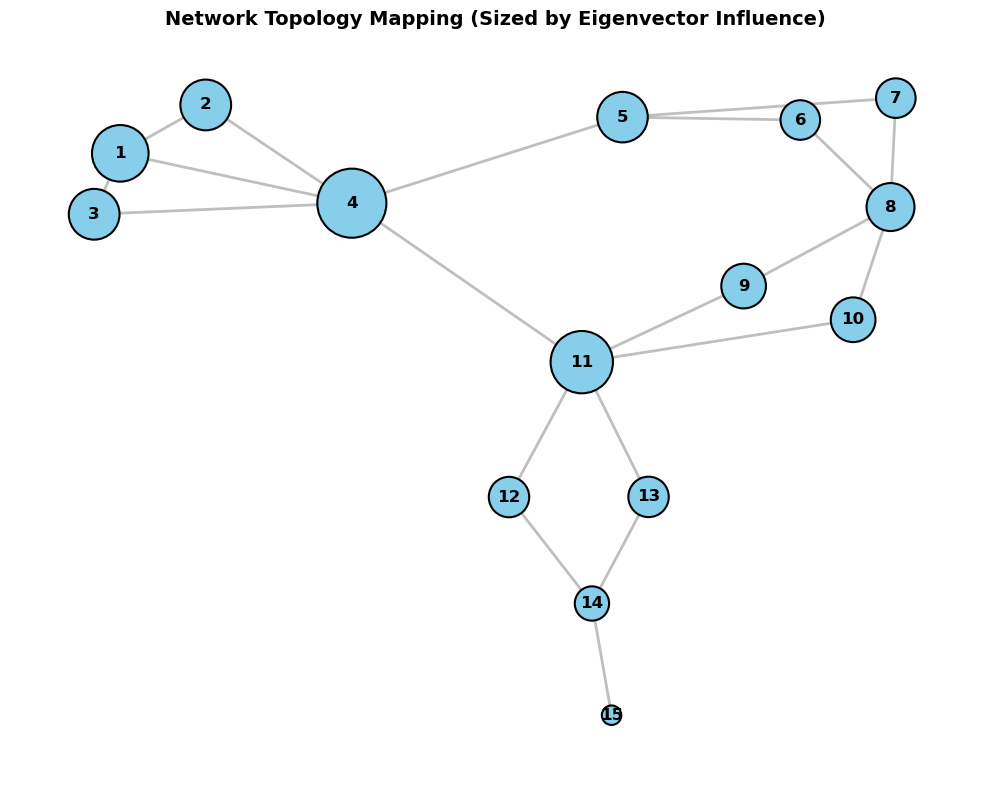

In [4]:
# Calculate Centralities
degree_cent = nx.degree_centrality(G)
eigen_cent = nx.eigenvector_centrality(G, max_iter=1000)
pagerank_cent = nx.pagerank(G)

# Compile results into a Pandas DataFrame for professional Data Science formatting
results = pd.DataFrame({
    'Node': list(G.nodes()),
    'Degree Centrality': list(degree_cent.values()),
    'Eigenvector Centrality': list(eigen_cent.values()),
    'PageRank': list(pagerank_cent.values())
})

# Sort by Eigenvector Centrality (The most mathematically complex metric)
results = results.sort_values(by='Eigenvector Centrality', ascending=False).round(4)
print("🏆 Top 5 Most Influential Nodes in the Network:\n")
print(results.head())

# --- VISUALIZATION ---
# Size the nodes based on their Eigenvector Centrality
node_sizes = [v * 5000 for v in eigen_cent.values()]

plt.figure(figsize=(10, 8))
plt.title("Network Topology Mapping (Sized by Eigenvector Influence)", fontsize=14, fontweight='bold')

# Draw the network
pos = nx.spring_layout(G, seed=42) # Seed for consistent layout
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', edgecolors='black', linewidths=1.5)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif", font_weight='bold')

plt.axis('off')
plt.tight_layout()
plt.show()